In [2]:
#Imports
#Pytorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, TensorDataset
from torch.utils.data import DataLoader

#Sci-kit learn
import sklearn.model_selection

#Numpy
import numpy as np

#Matplotlib
import matplotlib.pyplot as plt

#Dataset
from mlxtend.data import mnist_data

In [3]:
device = torch.device('cpu')
if torch.cuda.is_available():
    cuda = torch.device('cuda')
    print(torch.version.cuda)
    print(torch.cuda.current_device())
    print(torch.cuda.device(0))
    print(torch.cuda.device_count())
    print(torch.cuda.get_device_name(0))
    t = torch.cuda.get_device_properties(0).total_memory
    print(t/1e6)
    r = torch.cuda.memory_reserved(0)
    a = torch.cuda.memory_allocated(0)
    f = r-a
    print('reserved memory',r)
    print('allocated memory',a)
    print('free memory',f/1e6)
else:
    print('no cuda available')

11.8
0
1
NVIDIA GeForce GTX 1650 Ti
4294.705152
reserved memory 0
allocated memory 0
free memory 0.0


In [4]:
print('current reserved memory: ', torch.cuda.memory_reserved(0))
print('current allocated memory: ', torch.cuda.memory_allocated(0))
print('available CUDA devices: ', torch.cuda.device_count())

current reserved memory:  0
current allocated memory:  0
available CUDA devices:  1


In [5]:
#Importing the data
X, y = mnist_data()
#Separate data into 70% training data and 30% testing data
Xtrain, Xtest, ytrain, ytest = sklearn.model_selection.train_test_split(X,y,test_size=0.3,shuffle=True)
#Prepare dataset
trainDataset = TensorDataset(torch.tensor(Xtrain).float(), torch.tensor(ytrain).float()) #Combine train data and train labels
testDataset = TensorDataset(torch.tensor(Xtest).float(), torch.tensor(ytest).float())

In [20]:
class myNet2(nn.Module): #this class inherits from nn.Module which is required to use PyTorch's model-building features
    def __init__(self): #Initialize layers and other properties
        super().__init__() #Call constructor of parent class nn.Module
        self.inputLayer = nn.Linear(784, 256, bias=True) #Defining a fully-connected (linear) layer with 784 inputs and 10 output (10 digits)
        self.layer_one = nn.Linear(256, 128, bias=True)
        self.layer_two = nn.Linear(128, 64, bias=True)
        self.layer_three = nn.Linear(64, 32, bias=True)
        self.layer_four = nn.Linear(32, 16, bias=True)
        self.outputLayer = nn.Linear(16, 10, bias=True)
        
        self.Softmax = nn.Softmax(dim=1)
        self.Relu = nn.ReLU()
        
    def forward(self, x):
        x = self.Relu(self.inputLayer(x)) #pass the data through the layer
        x = self.Relu(self.layer_one(x))
        x = self.Relu(self.layer_two(x))
        x = self.Relu(self.layer_three(x))
        x = self.Relu(self.layer_four(x))
        x = self.Softmax(self.outputLayer(x))
        return torch.squeeze(x)


0.9914285714285714


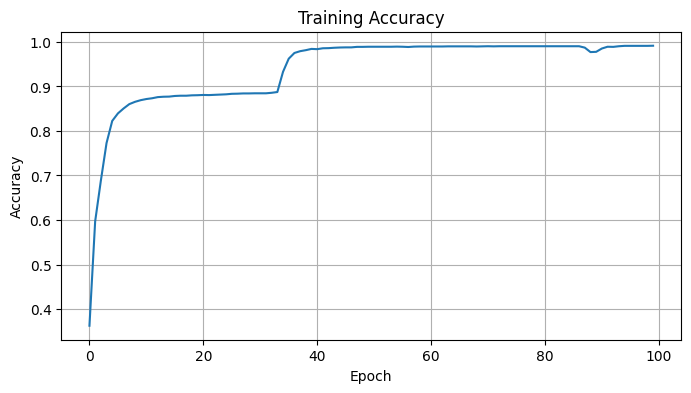

In [21]:
nEpoch = 100 #How many times all trainig data is used to train the model
learningRate = 0.0001
batchSize = 64 #Size of the training data batches

trainDataLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True) #Dataloader handles the feeding of a batch size at a time

model_C = myNet2() #Initialize the model

model_C.to(cuda) #Move the model to the GPU

optimizer = torch.optim.Adam(model_C.parameters(), lr=learningRate) #Using Adam to optimize (train) the network

accuracy = np.zeros(nEpoch)

for iEpoch in range(nEpoch):
    estimatedLabels = np.empty((0,))
    trueLabels = np.empty((0,))
    
    for xbatch, ybatch in trainDataLoader:
        # Move batch data to GPU
        xbatch = xbatch.to(cuda) 
        ybatch = ybatch.to(cuda)
        
        y_pred = model_C(xbatch)
        loss = nn.functional.cross_entropy(y_pred, ybatch.long()) #Calculate the loss using cross entropy
        
        model_C.zero_grad() #Make gradient zero before running the back propagation
        loss.backward()
        optimizer.step()
        
        yhat = torch.argmax(y_pred, dim=1) #What digit has the highest prediction
        estimatedLabels = np.append(estimatedLabels, torch.Tensor.cpu(yhat))
        trueLabels = np.append(trueLabels, torch.Tensor.cpu(ybatch))
    
    accuracy[iEpoch] = np.mean(estimatedLabels==trueLabels)
   
print(accuracy[-1]) #Print the training accuracy for the last epoch
xax = np.linspace(0, nEpoch-1, nEpoch)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(xax, accuracy)
ax.set_title("Training Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.grid()
plt.show()

In [22]:
testDataLoader = DataLoader(testDataset, batch_size=batchSize, shuffle=True)
estimatedLabels = np.empty((0,))
trueLabels = np.empty((0,))
for xbatch, ybatch in testDataLoader:
    xbatch = xbatch.to(cuda)
    ybatch = ybatch.to(cuda)
    y_pred = model_C(xbatch)
    
    yhat = torch.argmax(y_pred, dim=1)
    estimatedLabels = np.append(estimatedLabels, torch.Tensor.cpu(yhat))
    trueLabels = np.append(trueLabels, torch.Tensor.cpu(ybatch))
    
testAccuracy = np.mean(estimatedLabels==trueLabels)
print(testAccuracy)

0.9353333333333333
